## Product-type 2 <통계>
- 데이터 로드
- 기술 통계량 확인
    - 공정/센서변수
    - 전체 샘플 수 대비 불량 제품의 비율
- 스피어만 상관계수 히트맵
    - 공정/센서변수
- histograms, Box-Plot
    - 공정/센서변수
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- Welch's T-test
    - 공정/센서변수
- Mann-Whitney U 검정
    - 공정/센서변수

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### **1. 데이터 로드**

In [2]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_2 = pd.read_csv('../data/for_통계_process_data_product-2.csv')
df_sensor_2 = pd.read_csv('../data/for_통계_sensor_data_product-2.csv')
df_defects_2 = pd.read_csv('../data/for_통계_defects_data_product-2.csv')
df_original_2 = pd.read_csv('../data/for_통계_overall_data_product-2.csv')

In [3]:
# 2. 데이터 크기 확인
print(f"제품 2의 전체 데이터 크기: {df_original_2.shape}")

print(f"제품 2의 process 관련 데이터 크기: {df_process_2.shape}")
print(f"제품 2의 sensor 관련 데이터 크기: {df_sensor_2.shape}")
print(f"제품 2의 defects 관련 데이터 크기: {df_defects_2.shape}")

제품 2의 전체 데이터 크기: (3328, 24)
제품 2의 process 관련 데이터 크기: (3328, 15)
제품 2의 sensor 관련 데이터 크기: (3328, 6)
제품 2의 defects 관련 데이터 크기: (3328, 3)


In [4]:
# 3-1. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 행을 기준으로 1이 존재하면 불량으로 처리할 예정
defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 3-2. 결함과 관련된 데이터프레임
df_defects_2['is_defect'] = df_defects_2[defect_cols].max(axis=1)
# 불량유형을 is_defect로 통합하고, 개별 불량 유형 컬럼은 삭제
df_defects_2_1 = df_defects_2.drop(columns=defect_cols)

display(df_defects_2_1.head(5))

,is_defect
0,0
1,0
2,0
3,0
4,0


In [5]:
# 3-3. 전체 데이터프레임
df_original_2['is_defect'] = df_original_2[defect_cols].max(axis=1)
# 불량유형을 is_defect로 통합하고, 개별 불량 유형 컬럼은 삭제
df_original_2_1 = df_original_2.drop(columns=defect_cols)

display(df_original_2_1.head(5))

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0
1,4208012_12,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
3,4210014_14,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
4,4211015_15,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0


In [6]:
# 3-6. 머신러닝을 위한 데이터 저장 (주석을 해제하면 저장 가능)
# df_original_2_1.to_csv("../data/ML_modeling_data_product-2.csv", index=False)

---
---
### **2. 기술통계**

#### 2.1 기술통계량 및 불량률 확인

In [8]:
# 1. 기술통계
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기초 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [9]:
create_statistics_summary(df_process_2, "공정(process)")
create_statistics_summary(df_sensor_2, "센서(sensor)")



공정(process) 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,3328.0,0.154473,0.004838,0.139,0.1515,0.156,0.158,0.162,-0.723734
velocity_2,3328.0,0.168620,0.004023,0.158,0.1660,0.168,0.172,0.178,0.066497
velocity_3,3328.0,0.202247,0.004953,0.184,0.2000,0.202,0.206,0.216,-0.215835
high_velocity,3328.0,2.553245,0.071882,2.470,2.5140,2.524,2.538,2.744,1.57937
cylinder_pressure,3328.0,264.764123,0.756067,247.000,265.0000,265.000,265.000,266.000,-15.937863
rapid_rise_time,3328.0,0.011660,0.000887,0.009,0.0110,0.012,0.012,0.014,-0.645471
biscuit_thickness,3328.0,17.589243,1.492139,2.000,17.0000,18.000,19.000,24.000,-1.538814
clamping_force,3328.0,370.342548,10.160827,346.000,361.0000,375.000,379.000,388.000,-0.470378
cycle_time,3328.0,35.704838,2.509634,33.600,35.8000,36.000,36.100,125.900,28.736696
pressure_rise_time,3328.0,0.036638,0.002946,0.031,0.0340,0.036,0.040,0.045,0.692732



센서(sensor) 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,3328.0,655.703996,8.494439,635.30,648.70,655.4,662.50,678.10,0.273951
air_pressure,3328.0,6.120583,0.677288,4.60,5.60,6.2,6.80,7.10,-0.378966
coolant_temp,3328.0,26.923347,0.551408,25.90,26.50,26.8,27.30,28.10,0.282971
coolant_pressure,3328.0,2.689742,0.056365,2.58,2.63,2.7,2.74,2.79,-0.210328
factory_temp,3328.0,32.571725,1.522960,27.40,31.60,32.0,32.50,37.00,1.401438
factory_humidity,3328.0,63.190775,6.631947,45.50,61.80,64.3,69.10,72.30,-1.083763


In [10]:
# 2. 전체 샘플 수 & 불량률
total    = len(df_original_2_1)
n_defect = df_original_2_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"=== 전체 데이터 대비 불량률 ===")
print(f"\n전체 샘플: {total:,}개")
print(f"불량인 제품: {int(n_defect):,}개")
print(f"정상인 제품: {int(n_normal):,}개")
print(f"불량률: {rate:.2f}%")
print('='*28)

=== 전체 데이터 대비 불량률 ===

전체 샘플: 3,328개
불량인 제품: 946개
정상인 제품: 2,382개
불량률: 28.43%


#### 2.2 기술통계 해석
**(1) 불량인 제품의 개수와 비율 확인**
product type 2의 데이터는 총 3,328개의 관측치로 구성되어 있으며, 정상인 제품이 2,3282개, 불량인 제품이 946개이므로 불량률이 약 28.43%이다.
> 정상 비율이 더 높지만 불량 비중도 무시하기 어려운 수준이므로, 이후 정상/불량 비교 통계에서도 두 집단의 차이를 함께 살펴볼 필요가 있다.

**(2) 공정관련 변수 (df_process) 데이터 기술통계량 해석**
- 공정 변수 대부분 평균과 중앙값의 차이가 크지 않고 분산도 비교적 크지 않아 전반적으로 좁은 범위에 분포하는 편이다. 하지만 `cycle_time`, `cylinder_pressure와` 같은 일부 변수들은 극단값의 영향이 강하게 나타난다.
> 따라서 제품유형 2의 공정 변수는 모든 변수가 균일한 정규형 분포를 따른다기보다, 일부 변수는 안정적이고 일부 변수는 치우침과 극단값의 영향을 함께 가지는 구조로 해석하는 것이 적절하다.

**(3) 환경관련 변수(df_sensor) 데이터 기술통계량 해석**
- 환경관련 변수는 전체적으로 공정 변수보다 비교적 안정적인 편이다. 다만 `factory_temp`, `factory_humidity` 등에서는 분포의 치우침이 확인된다.
> 따라서 환경관련 변수도 단순히 안정적이라고 해석하는 것보다, 일부 변수에서 비대칭성이 존재한다고 해석하는 것이 적절하다.

**(4) 기술통계량 해석 종합**
- 제품유형 2 데이터는 정상 제품이 더 많지만 불량 비율도 약 28% 수준으로 나타나, 품질 비교 분석의 의미가 충분하다.
> 기술통계량만 보았을 때 공정/환경관련 변수 모두 일부 변수에서 비대칭성과 극단값의 영향이 확인되므로,
이후 정규성 검정, 등분산성 검정등으로 정상과 불량 간 차이를 추가로 확인하는 흐름이 타당하다.

---
---
### **3. EDA 시행**

#### 3.1 스피어만 상관계수 히트맵

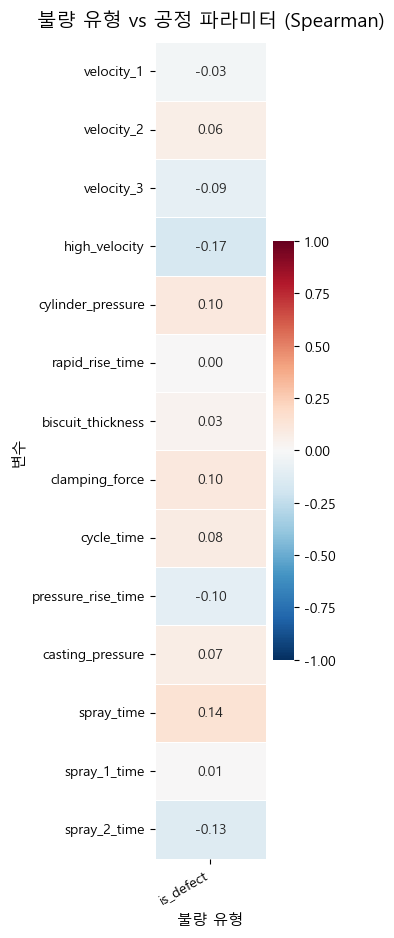

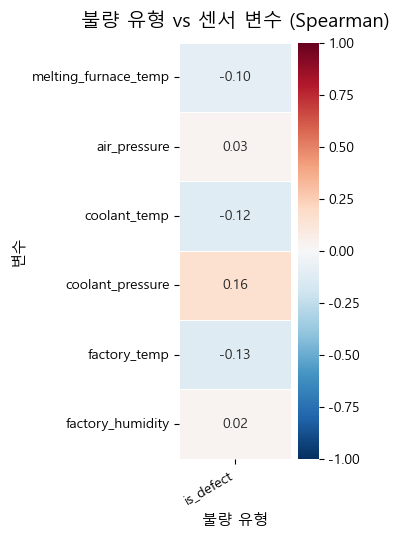

In [11]:
# 1. 변수 정의
DEFECT_COLS = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 2. 스피어만 상관계수 히트맵 시각화 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 3. 함수 출력
plot_corr_heatmap(df_original_2_1, DEFECT_COLS, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2_1, DEFECT_COLS, SENSOR_COLS, '불량 유형 vs 센서 변수 (Spearman)')

#### 3.2 스피어만 상관계수 해석
**(1) 공정관련 변수 (df_process) 데이터 절대값 기준 상위 2개**
    - high_velocity: -0.17
    - spray_time: 0.14

**(2) 센서관련 변수(df_sensor) 데이터 절대값 기준 상위 2개**
    - coolant_pressure: 0.16
    - factory_temp: -0.13 

**(3) 스피어만 상관계수 해석 종합**
- 제품유형 2에서 공정/환경관련 변수 모두에서 상관계수 절댓값이 대체로 0.00 ~ 0.17 수준으로 나타났으며, 전체적으로 상관계수 절댓값은 크지 않아 단일 변수 하나가 불량을 강하게 설명하는 구조는 아니었다.

다만 공정 변수에서는 `high_velocity`(-0.17), `spray_time`(0.14)이 상대적으로 큰 값을 보였고,
환경관련 변수에서는 `coolant_pressure`(0.16), `factory_temp`(-0.13)가 비교적 눈에 띄었다.

> 따라서 이들 변수를 우선 탐색 후보 변수로 선정하고, 히스토그램과 박스플롯을 통해 정상/불량 집단 간 분포 차이를 시각적으로 확인하였다. 
> 다만 불량은 단일 변수보다는 복합적인 조건(조합/임계값/비선형 관계)의 영향을 받을 가능성이 있어\
각 변수와 불량 여부 컬럼의 상관관계만으로 "불량의 원인"을 단정하지 않고,\
통계적 검정(Welch's T 검정/Mann-Whitney U 검정)방법과 머신러닝 모델 기반 중요도에서 함께 판단하는것이 적절하다고 판단된다.

#### 3.3 히스토그램 & 박스플롯

##### 3.3.1 히스토그램

In [12]:
# 1. histogram 시각화 함수 정의
import math

def plot_histograms(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    # 변수 1개당 1행, 정상/불량 2열
    n_rows = len(cols)

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 3.5))
    
    # 변수 1개일 때도 2차원 형태 유지
    if n_rows == 1:
        axes = axes.reshape(1, 2)

    for i, col in enumerate(cols):
        # 정상
        sns.histplot(
            data=df_a[df_a["is_defect"] == "정상"],
            x=col,
            bins=30,
            stat="density",
            kde=True,
            color="#4E4CB0",
            alpha=0.4,
            ax=axes[i, 0]
        )
        axes[i, 0].set_title(f"{col} - 정상", fontsize=11, fontweight="bold")
        axes[i, 0].set_xlabel("")
        axes[i, 0].set_ylabel("Density")

        # 불량
        sns.histplot(
            data=df_a[df_a["is_defect"] == "불량"],
            x=col,
            bins=30,
            stat="density",
            kde=True,
            color="#DD5252",
            alpha=0.4,
            ax=axes[i, 1]
        )
        axes[i, 1].set_title(f"{col} - 불량", fontsize=11, fontweight="bold")
        axes[i, 1].set_xlabel("")
        axes[i, 1].set_ylabel("Density")

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

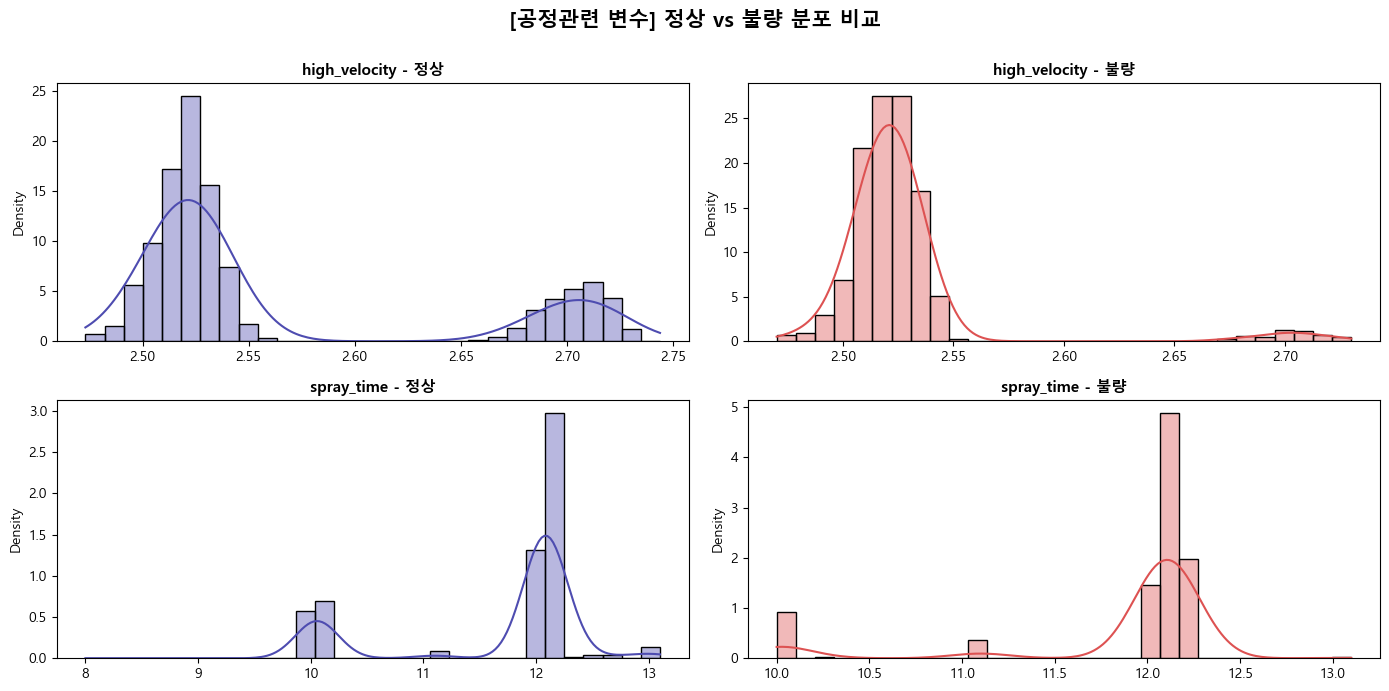

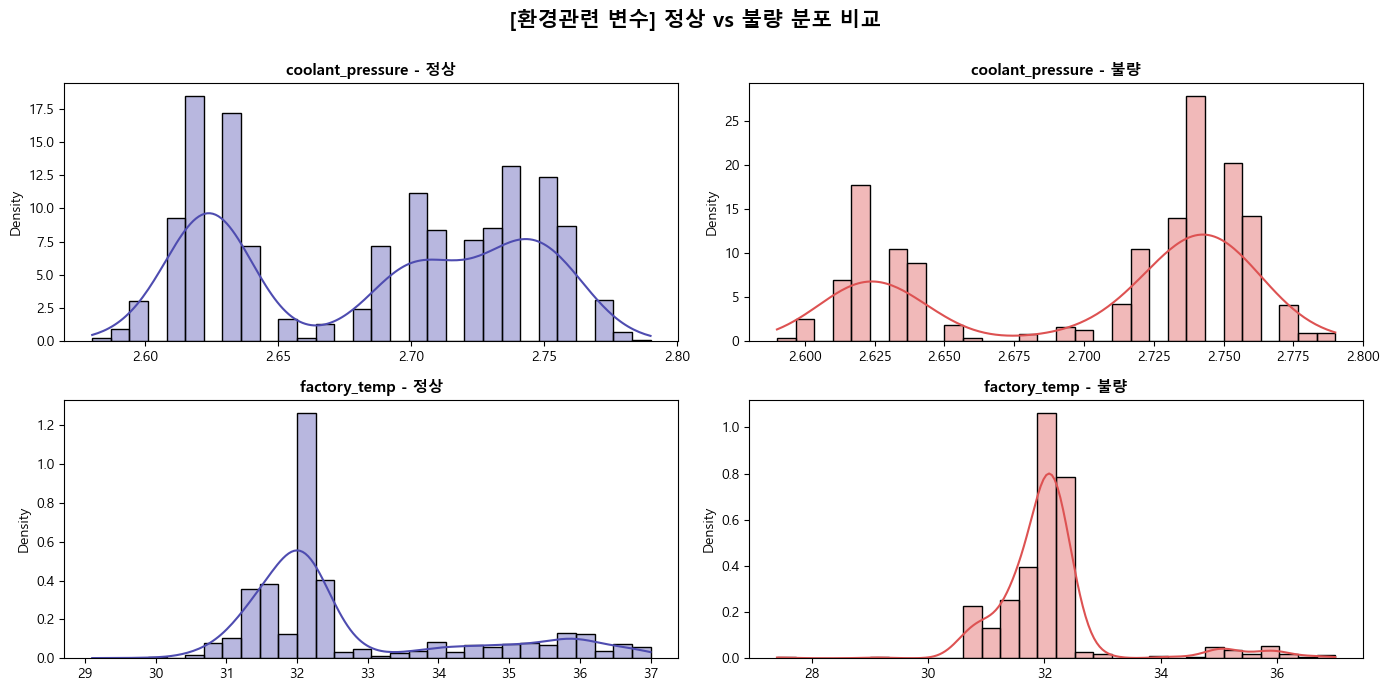

In [13]:
histogram_of_process_2 = plot_histograms(
    df_original_2_1,
    ["high_velocity", "spray_time"],
    "공정관련 변수"
)

histogram_of_sensor_2 = plot_histograms(
    df_original_2_1,
    ["coolant_pressure", "factory_temp"],
    "환경관련 변수"
)

##### 3.3.2 히스토그램 해석
- 제품유형 2에서 스피어만 상관계수 절대값 기준 상위 후보로 선정된 아래 변수에 대해 정상/불량 집단으로 구분하여 히스토그램을 확인하였다.
    - 공정 변수 `high_velocity`, `spray_time`
    - 센서 변수 `coolant_pressure`, `factory_temp`

**(1) 공정관련 변수 (df_process) 관점**
- `high_velocity`: 정상과 불량 모두 유사한 분포 형태를 보이나, 불량 집단이 정상 집단보다 조금 더 낮은 값 구간에 집중되는 경향이 보인다.
- `spray_time`: 정상과 불량 모두 약 12 부근에 값이 몰려 있으나, 불량 집단이 약간 더 높은 방향으로 분포하는 모습이 보인다. 다만 두 집단의 분포 겹침이 커 시각적 차이는 크지 않다.

**(2) 센서관련 변수(df_sensor) 관점**
- `coolant_pressure`: 정상과 불량 모두 유사한 구간에 분포하지만, 불량 집단이 조금 더 높은 값 구간에 많이 분포하는 경향이 보인다.
- `factory_temp`: 정상과 불량 모두 32도 부근에 중심이 형성되어 있지만, 정상 집단이 더 넓게 퍼지고 오른쪽 꼬리가 길게 나타난다.

##### 3.3.3 박스플롯

In [14]:
# 1. box plot 시각화 함수 정의
def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#534CB0", "불량": "#DD5252"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 비어있는 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

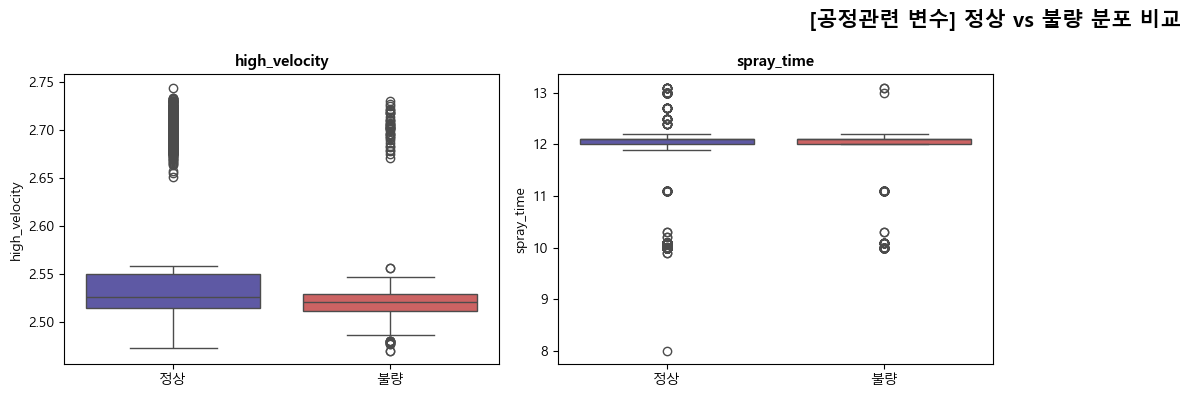

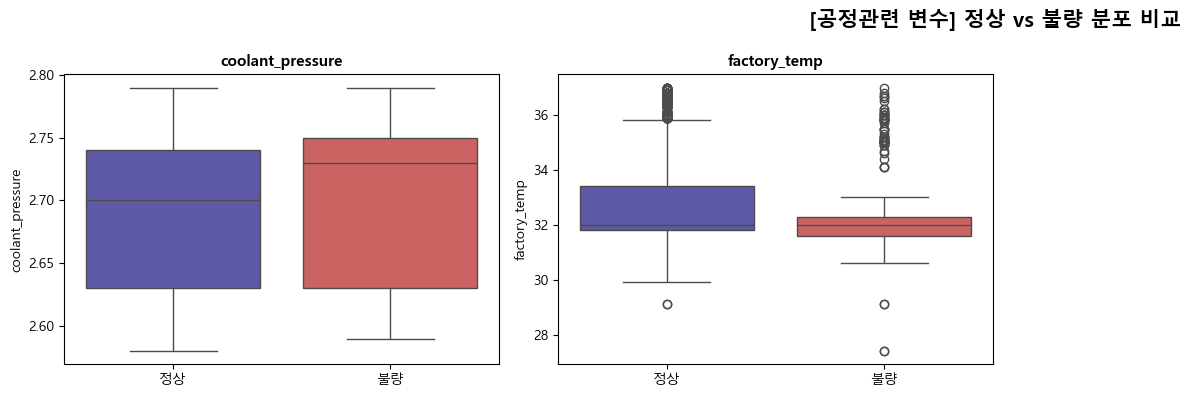

In [15]:
boxplot_of_process_2 = plot_boxplots(
    df_original_2_1,
    ["high_velocity", "spray_time"],
    "공정관련 변수"
)

boxplot_of_sensor_2 = plot_boxplots(
    df_original_2_1,
    ["coolant_pressure", "factory_temp"],
    "공정관련 변수"
)

##### 3.3.4 박스플롯 해석
- 제품유형 2에서 스피어만 상관계수 절대값 기준 상위 후보로 선정된 아래 변수에 대해 정상/불량 집단으로 구분하여 박스플롯을 확인하였다.
    - 공정 변수 `high_velocity`, `spray_time`
    - 센서 변수 `coolant_pressure`, `factory_temp`


**(1) 공정관련 변수 (df_process) 관점**
- `high_velocity`: 불량 집단의 중앙값이 정상 집단보다 약간 낮게 나타나, 히스토그램에서 보인 방향성과 유사한 흐름을 보인다.\다만 두 집단의 박스가 상당 부분 겹쳐 차이가 아주 크다고 보기는 어렵다.
- `spray_time`: 정상과 불량의 중앙값 차이는 크지 않고, 전반적으로 박스가 많이 겹쳐 보조적인 차이 정도로 해석하는 것이 적절하다.


**(2) 환경관련 변수(df_sensor) 관점**
- `coolant_pressure`: 불량 집단의 중앙값이 정상 집단보다 약간 높게 나타나며, 박스 위치도 조금 위쪽에 형성되어 있다.
- `factory_temp`: 정상과 불량의 중앙값 차이는 크지 않지만, 정상 집단이 더 넓은 분포와 더 많은 이상치를 보인다.

#### 3.4 히스토그램 & 박스플롯 종합 해석
- 제품유형 2에서 스피어만 상관계수 절대값 기준 상위 후보 변수들을 대상으로 히스토그램과 박스플롯을 확인한 결과, 일부 변수에서는 정상과 불량 집단 간의 분포 차이가 시각적으로 관찰되었다.

- 공정 변수에서는 `high_velocity`, `spray_2_time`가, 환경관련 변수에서는 `coolant_pressure`가 상대적으로 차이가 더 눈에 띄는 후보로 보인다.

- 아래와 같은 한계점이 확인되었다.
(1) 정상과 불량 집단의 분포가 상당 부분 겹치는 변수들이 많음
(2) 일부 변수는 특정 값에 강하게 집중됨 (`spray_2_time` 등)
(3) 일부 변수는 중앙값 차이보다 분산 차이 또는 분포 형태 차이가 더 큼
(4) 시각화만으로 실제 차이의 통계적 유의성을 단정하기 어려움


> 따라서 EDA 과정에서는 이들 변수가 정상/불량 간 차이를 보일 가능성이 있는 후보 변수임을 확인할 수 있었으나, 시각화만으로 실제 차이의 유의성을 단정하기에는 한계가 있어 통계/검정을 함께 확인하는 것이 적절하다.

---
---
### **4. 정규성 검정**

#### 4.1 Shapiro-Wilk 검정

In [16]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary_by_group(df, df_name, group_col="is_defect", exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정: 정상/불량 그룹별"""
    
    print(f"\n{'='*80}")
    print(f"{df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk, 그룹별)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    result_dict = {}

    # 그룹별 반복
    for group_value, group_name in [(0, "정상"), (1, "불량")]:
        print(f"\n[그룹: {group_name}]")
        
        group_df = df_copied[df_copied[group_col] == group_value].copy()
        
        # 숫자형 컬럼만 선택
        group_df = group_df.select_dtypes(include="number")
        
        # group_col 제외
        group_df = group_df.drop(columns=[group_col], errors="ignore")

        # 출력값 저장
        result_list = []

        for col in group_df.columns:
            series = group_df[col].dropna()

            # 정규성 확인: Shapiro-Wilk
            stat, p_value = stats.shapiro(series)

            # H0: 정규성을 만족한다.
            # H1: 정규성을 불만족한다.
            if p_value >= alpha:
                result = "정규성 만족"
            else:
                result = "정규성 불만족"

            # 출력값
            result_list.append([
                col, 
                stat, 
                p_value,
                result
            ])

        # 출력화면
        shapiro_df = pd.DataFrame(
            result_list,
            columns=[
                "변수명", 
                "Shapiro 검정통계량", 
                "p-value", 
                "판정"]
        ).set_index("변수명")

        display(shapiro_df)
        result_dict[group_name] = shapiro_df

    return result_dict

In [17]:
# 2. 함수 실행
shapiro_process_2 = create_shapiro_summary_by_group(
    df_original_2_1[["is_defect"] + PROCESS_COLS],
    "공정 변수"
)


공정 변수 관련 데이터 정규성 검정 (Shapiro-Wilk, 그룹별)


[그룹: 정상]


,Shapiro 검정통계량,p-value,판정
변수명,,,
velocity_1,0.921642,1.623307e-33,정규성 불만족
velocity_2,0.969636,4.821996e-22,정규성 불만족
velocity_3,0.984381,1.651957e-15,정규성 불만족
high_velocity,0.691533,1.366418e-54,정규성 불만족
cylinder_pressure,0.307597,1.602146e-69,정규성 불만족
rapid_rise_time,0.762058,3.436977e-50,정규성 불만족
biscuit_thickness,0.907733,9.472429e-36,정규성 불만족
clamping_force,0.896508,2.299646e-37,정규성 불만족
cycle_time,0.154327,1.683150e-73,정규성 불만족



[그룹: 불량]


,Shapiro 검정통계량,p-value,판정
변수명,,,
velocity_1,0.936182,1.079251e-19,정규성 불만족
velocity_2,0.966050,4.831108e-14,정규성 불만족
velocity_3,0.982582,3.385659e-09,정규성 불만족
high_velocity,0.507856,3.740364e-45,정규성 불만족
cylinder_pressure,0.166275,1.651996e-53,정규성 불만족
rapid_rise_time,0.755580,3.413529e-35,정규성 불만족
biscuit_thickness,0.844741,2.002649e-29,정규성 불만족
clamping_force,0.854453,1.198431e-28,정규성 불만족
cycle_time,0.568400,3.463427e-43,정규성 불만족


In [18]:
shapiro_sensor_2 = create_shapiro_summary_by_group(
    df_original_2_1[["is_defect"] + SENSOR_COLS],
    "환경 변수"
)


환경 변수 관련 데이터 정규성 검정 (Shapiro-Wilk, 그룹별)


[그룹: 정상]


,Shapiro 검정통계량,p-value,판정
변수명,,,
melting_furnace_temp,0.980864,2.254705e-17,정규성 불만족
air_pressure,0.940853,7.564758e-30,정규성 불만족
coolant_temp,0.973069,9.006161e-21,정규성 불만족
coolant_pressure,0.895489,1.667976e-37,정규성 불만족
factory_temp,0.801336,3.034262e-47,정규성 불만족
factory_humidity,0.861968,1.403048e-41,정규성 불만족



[그룹: 불량]


,Shapiro 검정통계량,p-value,판정
변수명,,,
melting_furnace_temp,0.931620,2.247800e-20,정규성 불만족
air_pressure,0.946413,5.032981e-18,정규성 불만족
coolant_temp,0.964217,1.789787e-14,정규성 불만족
coolant_pressure,0.824336,6.104922e-31,정규성 불만족
factory_temp,0.725239,9.074856e-37,정규성 불만족
factory_humidity,0.860213,3.620508e-28,정규성 불만족


#### 4.2 Q-Q Plot

In [19]:
# 1. Q-Q plot
def plot_qq_table(df, cols=None, title=None, exclude_cols=None, group_col="is_defect", group_value=None):
    """Q-Q plot 그래프"""
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 그룹 필터링
    if group_value is not None:
        df_copied = df_copied[df_copied[group_col] == group_value]

    # cols 지정 시 그 컬럼만 사용
    if cols is not None:
        cols = [col for col in cols if col in df_copied.columns]
    else:
        cols = df_copied.select_dtypes(include='number').columns.tolist()
        if group_col in cols:
            cols.remove(group_col)
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

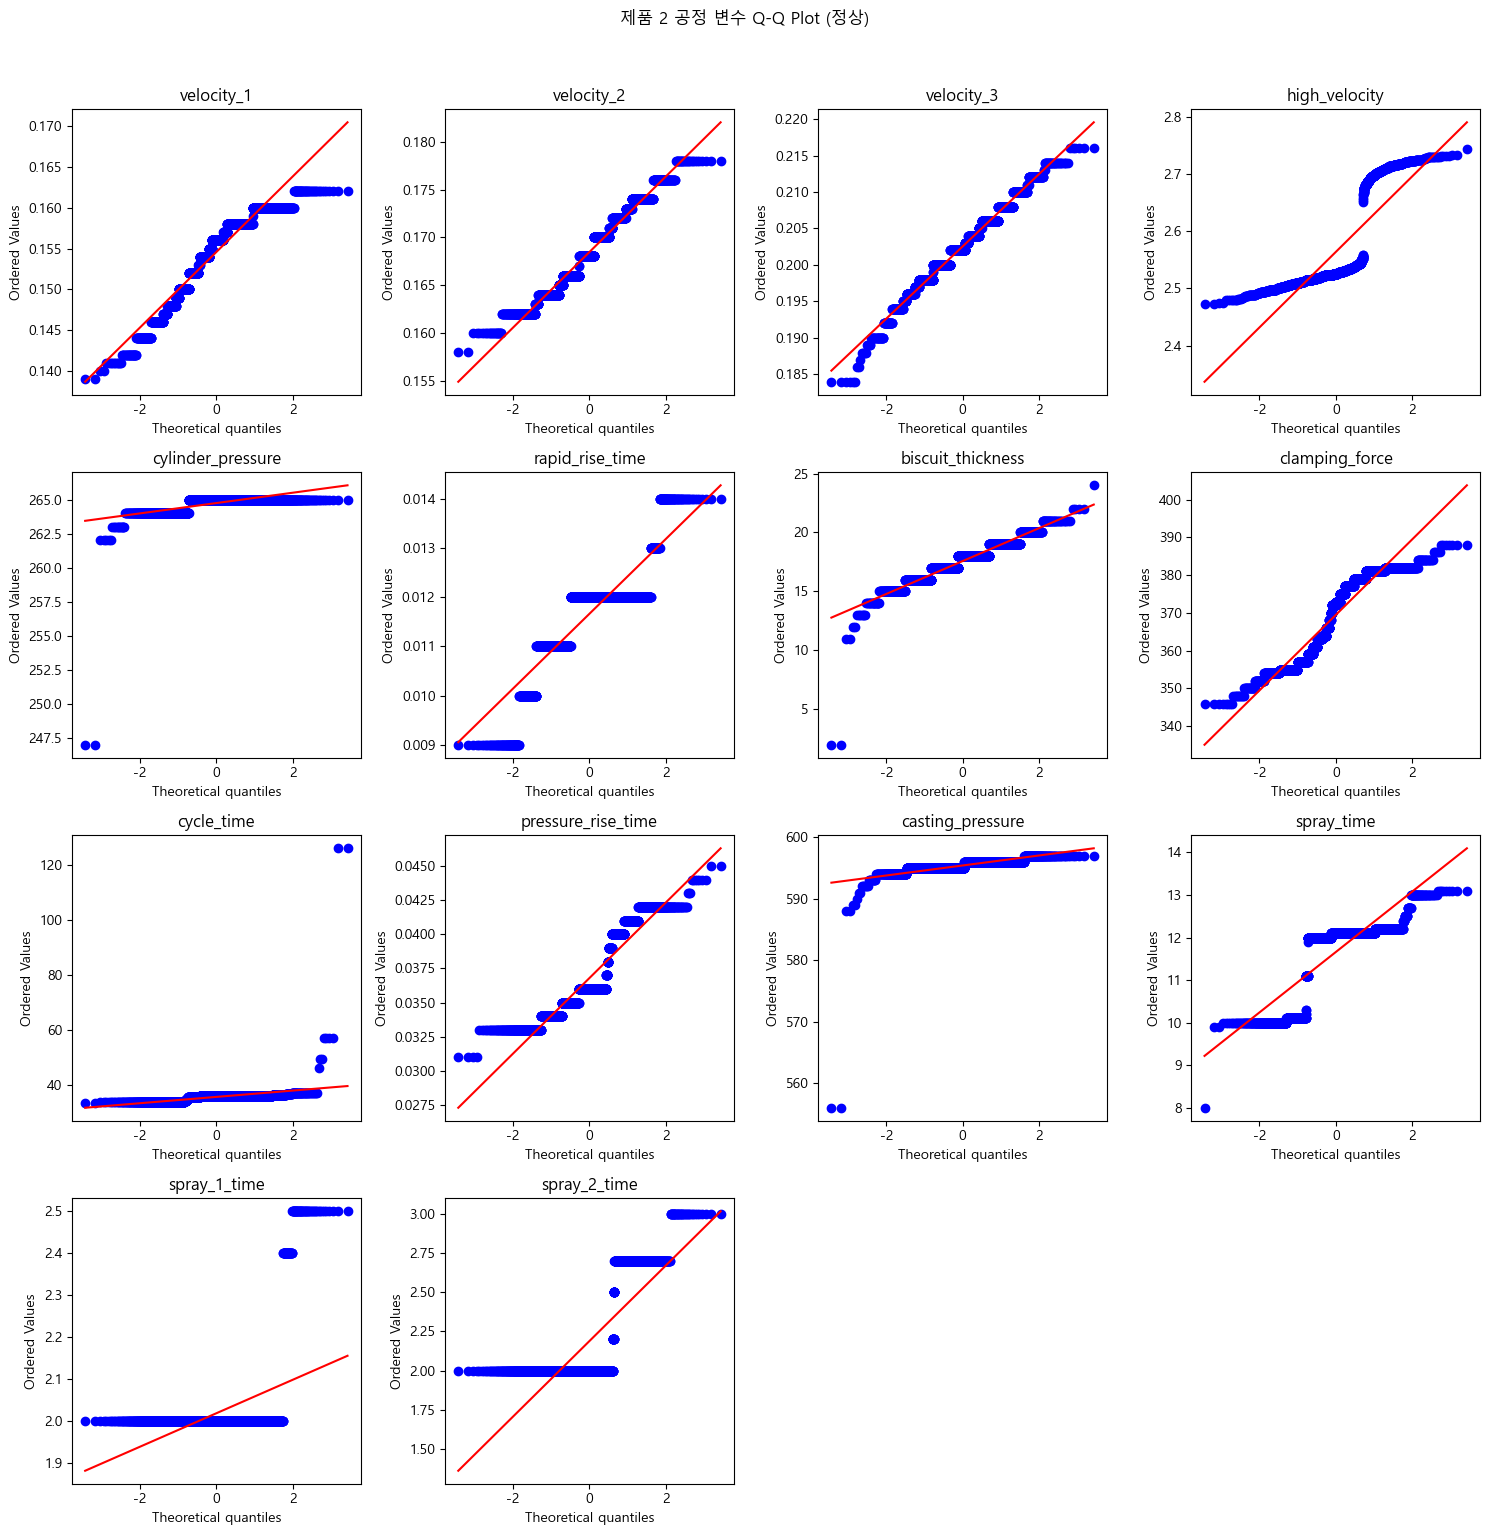

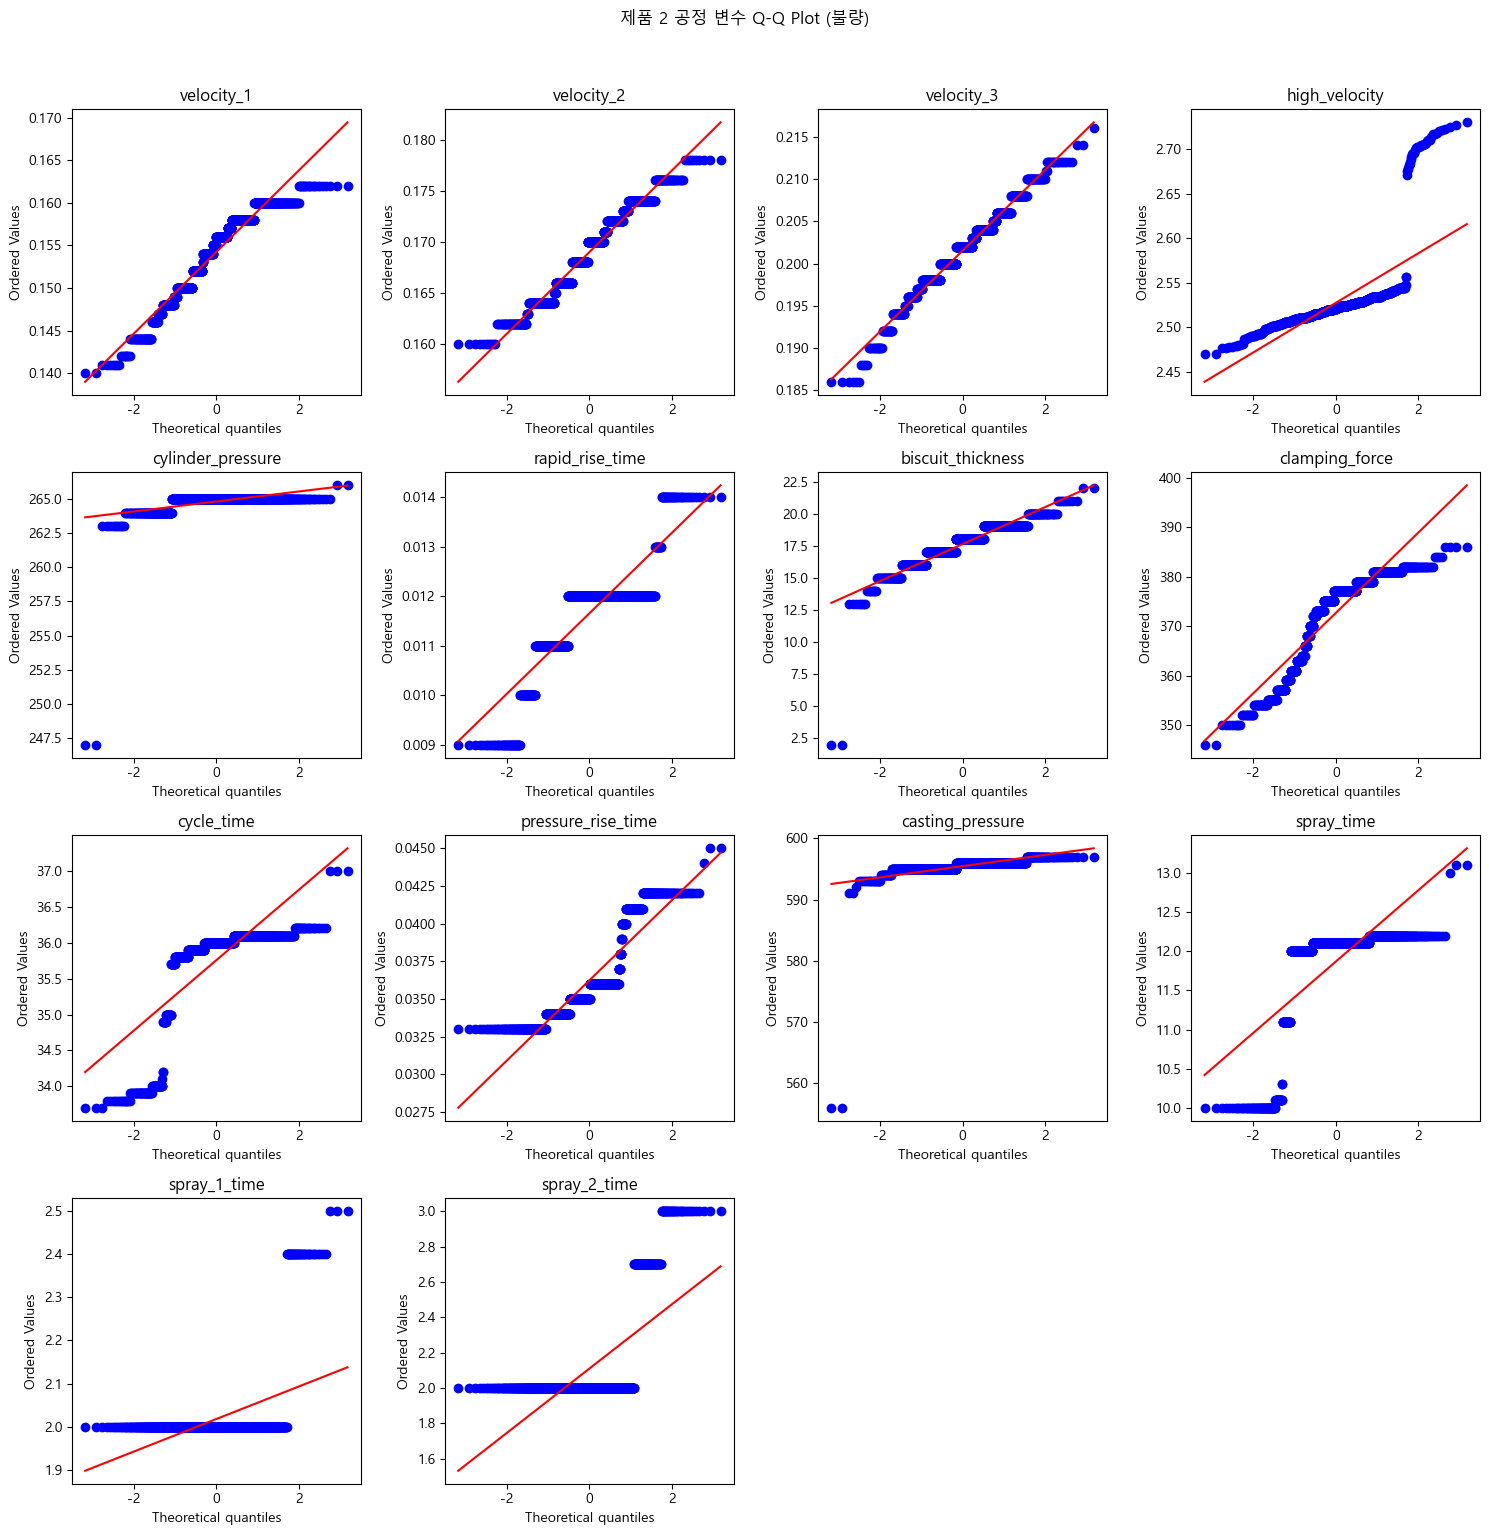

In [20]:
# 2. 함수 실행
# 제품 2 - 공정 변수 - 정상
plot_qq_table(
    df_original_2_1,
    cols=PROCESS_COLS,
    title="제품 2 공정 변수 Q-Q Plot (정상)",
    group_value=0
)

# 제품 2 - 공정 변수 - 불량
plot_qq_table(
    df_original_2_1,
    cols=PROCESS_COLS,
    title="제품 2 공정 변수 Q-Q Plot (불량)",
    group_value=1
)

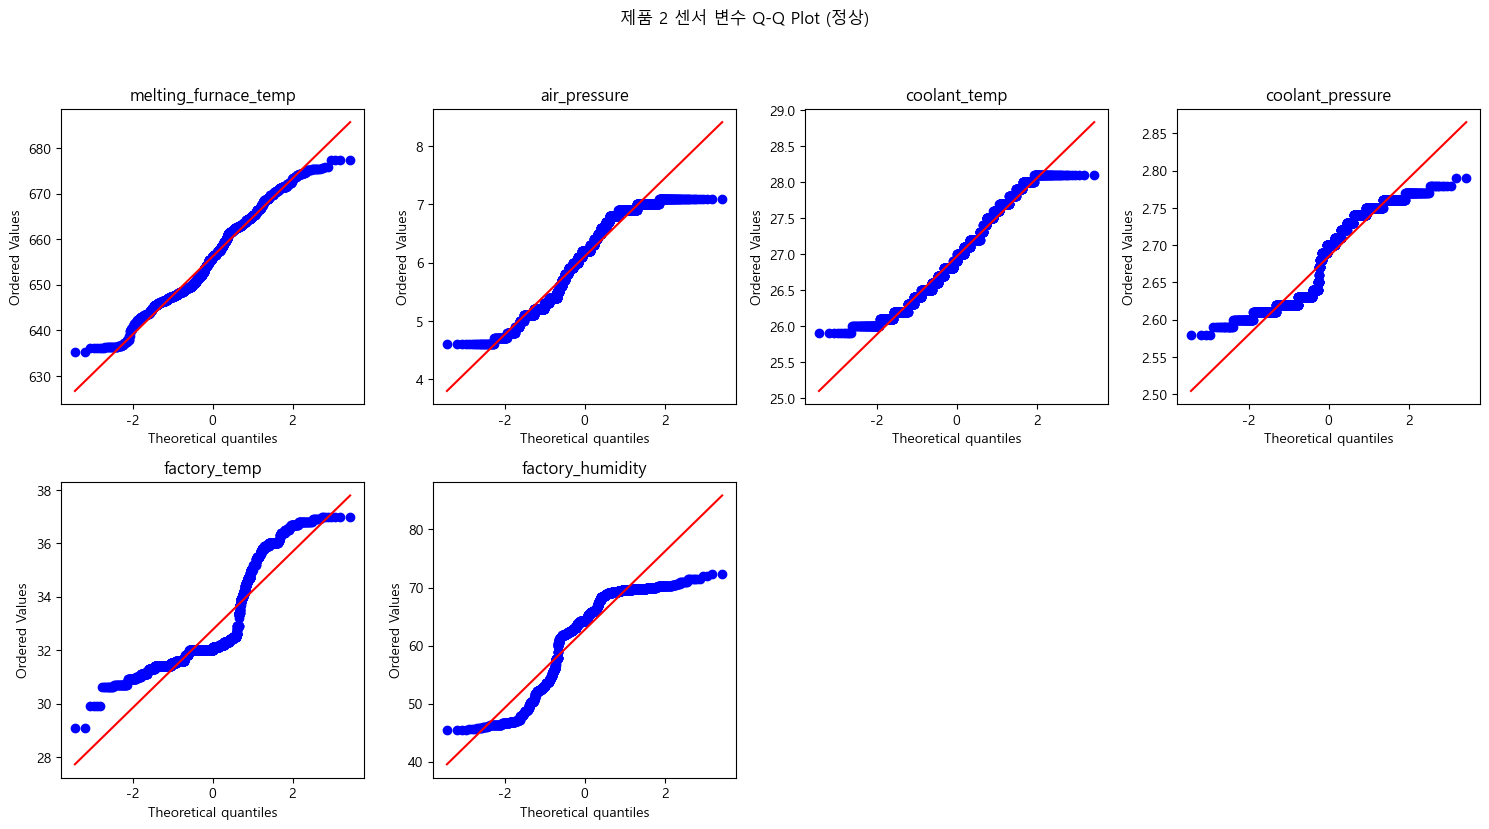

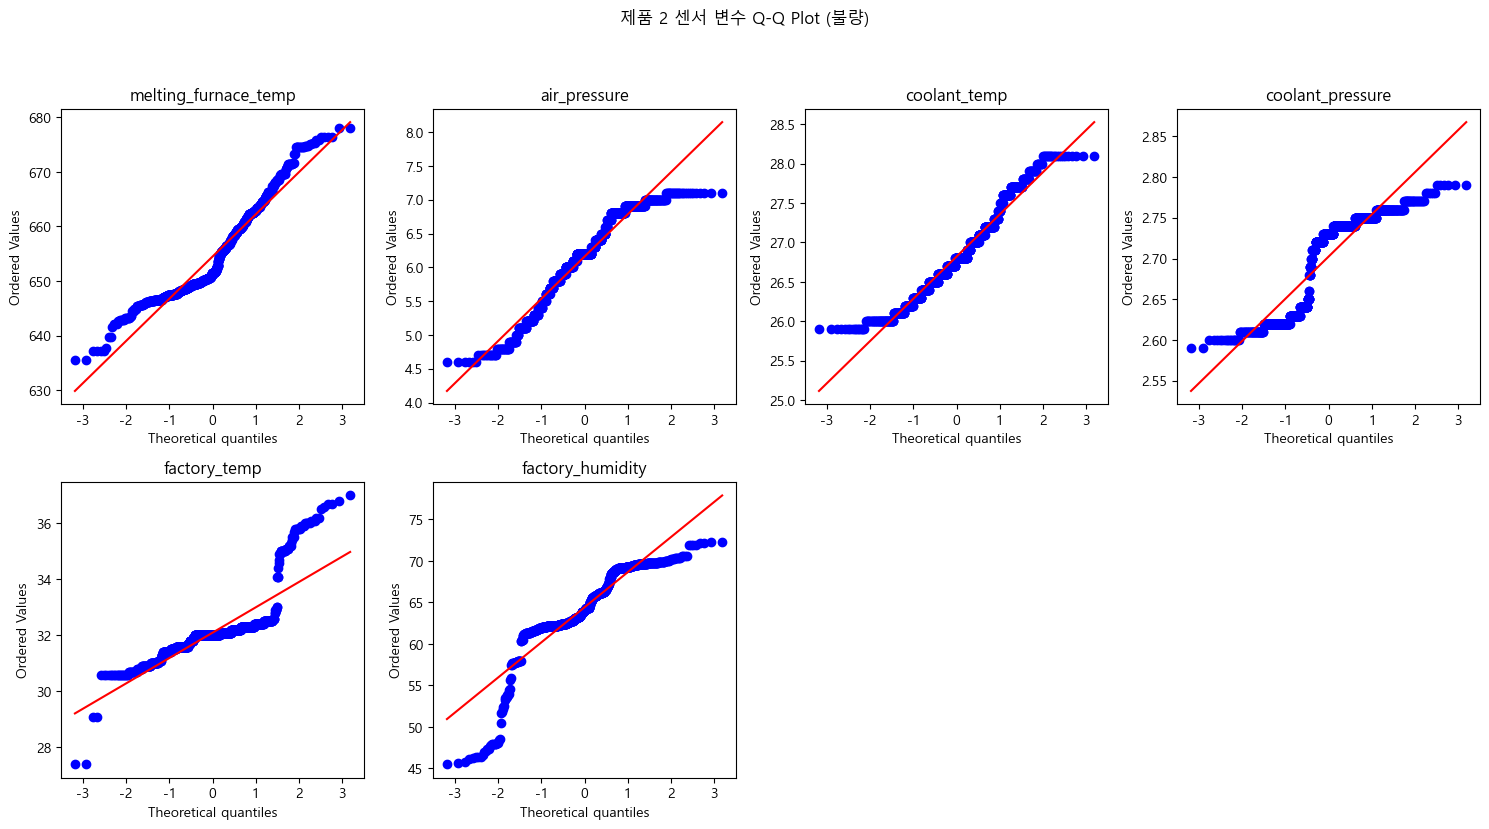

In [21]:
# 제품 2 - 센서 변수 - 정상
plot_qq_table(
    df_original_2_1,
    cols=SENSOR_COLS,
    title="제품 2 센서 변수 Q-Q Plot (정상)",
    group_value=0
)

# 제품 2 - 센서 변수 - 불량
plot_qq_table(
    df_original_2_1,
    cols=SENSOR_COLS,
    title="제품 2 센서 변수 Q-Q Plot (불량)",
    group_value=1
)

#### 4.3 정규성 검정 분석 결과
**1. Shapiro-Wilk**
- 공정 및 센서과 관련된 모든 변수에서 p-value가 거의 0으로 정규성을 만족하지 못한다.\
다만, 표본 수가 3328개로 큰 편으로, Shapiro–Wilk 검정은 분포가 조금만 비대칭이거나 이산적이어도 정규성이 쉽게 기각될 수 있다.
> 따라서 p-value만 보고 "완전 비정규다"라 단정하기보단 Q-Q plot도 함께 확인하여 분포 형태를 종합적으로 해석하는 것이 적절하다.

**2. Q-Q plot 해석**

(1) **공정관련 변수의 Q–Q plot**: 값 대부분을 정규성 분포로 보기 어렵다.
- 대부분 점들이 기준 직선 위에 고르게 놓이지 않고 중간 또는 꼬리 구간에서 이탈하는 모습이 확인되어 정규분포를 따른다 하기 어렵다.
- 특히 일부 변수는 점들이 계단 형태로 나타나 연속형 정규분포로 보기 어려운 패턴이 관찰된다. (`velocity`, `rapid_rise_time` 등)
> 즉, 공정 변수는 전반적으로 정규분포보다는 비대칭성, 반복값, 꼬리 이탈이 함께 나타나는 구조로 해석 가능하다.

(2) **환경관련 변수의 Q–Q plot**: 값 대부분을 정규성 분포로 보기 어렵다.
- 직선에서 벗어나는 구간이 존재하며, 일부 변수는 꼬리 부분에서 이탈이 나타난다.
    - `factory_temp`, `factory_humidity는` 한쪽 꼬리가 더 길게 나타나는 비대칭성이 확인되며, 나머지 변수들도 완전한 정규분포라고 보기에는 어려운 형태를 보인다.
- 환경관련 변수의 특성상 데이터 분포상 꼬리가 생길 수 있으나 전반적으로 정규분포로 보기에는 부적합한 형태가 확인된다.

**3. 정규성 검정 결과 종합**
- 제품유형 2의 공정 및 센서 변수는 Shapiro-Wilk 검정과 Q-Q plot을 종합했을 때, 전반적으로 정규분포를 따른다고 보기 어렵다.
> 따라서 이후 집단 비교에서는 Welch’s t-test 결과를 참고하되 Mann-Whitney U 검정과 함께 해석하는 접근이 타당하다.

#### 4.4 Levene 검증

In [22]:
from scipy.stats import levene

# 1. 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력할 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [23]:
# 2. 함수 실행
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2_1,
    "is_defect",
    "df_process_2",
    exclude_cols=['shot_key']
)


df_process_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,4.480292,3.436193e-02,등분산 가정 불가
velocity_2,0.730217,3.928743e-01,등분산 가정 가능
velocity_3,1.830792,1.761259e-01,등분산 가정 가능
high_velocity,188.751329,8.084364e-42,등분산 가정 불가
cylinder_pressure,5.546086,1.857985e-02,등분산 가정 불가
rapid_rise_time,0.714535,3.980031e-01,등분산 가정 가능
biscuit_thickness,0.580366,4.462228e-01,등분산 가정 가능
clamping_force,163.045258,1.734345e-36,등분산 가정 불가
cycle_time,15.444339,8.669984e-05,등분산 가정 불가


In [24]:
process_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2_1,
    "is_defect",
    "df_sensor_2",
)


df_sensor_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,19.173745,1.230211e-05,등분산 가정 불가
air_pressure,24.267707,8.792250e-07,등분산 가정 불가
coolant_temp,3.906079,4.819422e-02,등분산 가정 불가
coolant_pressure,7.258745,7.091103e-03,등분산 가정 불가
factory_temp,108.956851,4.036253e-25,등분산 가정 불가
factory_humidity,176.767310,2.442028e-39,등분산 가정 불가


#### 4.5 등분산성(Levene) 결과 해석
**1. 공정관련 변수 (df_process)(is_defect 기준)**\
- `high_velocity`, `clamping_force`, `cycle_time`, `spray_time`, `spray_2_time` 등의 변수는 등분산 가정이 기각되었다.
- `velocity_2`, `velocity_3`, `rapid_rise_time`, `biscuit_thickness`, `pressure_rise_time`, - `casting_pressure` 등의 변수는 등분산 가정이 성립할 것으로 판단된다.
> 따라서 공정관련 변수 (df_process)는 등분산성이 변수별로 혼재되어 있으나, 등분산 가정이 기각되는 변수도 적지 않다.

**2. 환경관련 변수(df_sensor) (is_defect 기준)**
- 모든 항목에서 p-value가 매우 작아 등분산 가정이 모두 불가능한 것으로 판단된다.\
> 즉, 환경관련 데이터는 정상 제품과 불량 제품 간 분산 차이가 전반적으로 존재하는 것으로 해석할 수 있다.


**3. 등분산성 검정 결과 종합**
- 제품유형 2에서는 공정 변수는 일부만 등분산 가정을 만족하고, 센서 변수는 전반적으로 등분산 가정이 성립하지 않았다.
> 따라서 이후 정상/불량 간 평균 비교에서는 등분산을 가정하는 Student's t-test보다 Welch's t-test를 사용하는 것이 더 적절하다. 또한 정규성도 만족하지 않았기 때문에, Welch's t-test 결과와 함께 Mann-Whitney U 검정 결과도 병행하여 해석하는 흐름이 타당하다.

---
---
### **5. 통계적 검정**

#### 5.1 Welch's T-test

In [26]:
# 1. 효과크기 계산 함수
def cohens_d_ind(group1, group2): # 독립표본 d(합동표준편차 사용)
    """Cohen's d — 독립표본: d = |x̄₁ - x̄₂| / s_pooled"""
    n1, n2 = len(group1), len(group2)
    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) # 합동 분산 
    return abs(np.mean(group1) - np.mean(group2)) / s_pooled

In [27]:
from scipy.stats import ttest_ind

# 2. Welch t-test 검정 + Cohen's d 효과크기
def create_welch_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """Welch t-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Welch t-test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
    
        # 통계검정: Welch t-검정 (등분산 가정 X)
        # 양측검정 (two-sided)
        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False, alternative='two-sided')
        
        # 효과크기: Cohen's d
        cohen_d = cohens_d_ind(group_0, group_1)
    
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 평균이 같다. (μ0 = μ1)
        # 대립가설(H1): 두 집단의 평균이 다르다. (μ0 ≠ μ1)
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(cohen_d) < 0.1:
            effect = "매우 작은 효과"
        elif abs(cohen_d) < 0.3:
            effect= "작은 효과"
        elif abs(cohen_d) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력할 값
        result_list.append([
            col,
            t_stat,
            cohen_d,
            effect,
            p_value,
            result
        ])


    # 출력화면 조정
    welch_df = pd.DataFrame(
        result_list,
        columns=[
            "변수",
            "t-통계량", 
            "Cohen's d", 
            "효과크기 판정",
            "p-value", 
            "통계적 유의성 여부"
        ]
    ).set_index("변수")
    
    # 효과크기의 절대값을 기준으로 내림차순 정렬
    welch_df = welch_df.sort_values("Cohen's d", key=abs, ascending=False)
    display(welch_df)
    
    return welch_df

In [28]:
welch_surface = create_welch_summary(
    df_original_2_1,
    df_defects_2_1,
    "is_defect",
    "df_original_2_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_2_1 실제 집단 차이 검정 (Welch t-test) - 기준: is_defect



,t-통계량,Cohen's d,효과크기 판정,p-value,통계적 유의성 여부
변수,,,,,
high_velocity,17.553665,0.515336,큰 효과,6.444589e-66,True
factory_temp,13.715566,0.441795,중간 효과,2.104785e-41,True
coolant_pressure,-8.175501,0.317986,중간 효과,5.711403e-16,True
clamping_force,-8.933557,0.317252,중간 효과,8.894569e-19,True
coolant_temp,6.806628,0.260440,작은 효과,1.367599e-11,True
factory_humidity,-8.148410,0.259178,작은 효과,5.567848e-16,True
spray_2_time,7.137874,0.259159,작은 효과,1.327725e-12,True
spray_time,-7.622387,0.257419,작은 효과,3.593887e-14,True
velocity_3,5.483617,0.207639,작은 효과,4.760016e-08,True


##### 5.2 Welch's t-test 결과 해석 (α=0.05)

**1. 공정관련 변수 (df_process)**

(1) 통계적으로 유의하게 나온 변수
- `velocity_2`, `velocity_3`, `high_velocity`, `cylinder_pressure`, `clamping_force`, `pressure_rise_time`, `spray_time`, `spray_2_time`

(2) 통계적으로 유의하지 않게 나온 변수
- `velocity_1`, `rapid_rise_time`, `biscuit_thickness`, `cycle_time`, `casting_pressure`, `spray_1_time`

(3) 효과크기 관점
- 중간 이상의 효과 크기를 가진 변수는 `high_velocity`, `factory_temp`, `coolant_pressure`, `clamping_force`이고, 그 외 나머지 변수는 작거나 매우 작은 효과 크기를 갖고 있다. 특히, `high_velocity`는 p-value가 매우 작고 효과 크기도 가장 크게 나타나, 공정 변수 중 가장 우선적으로 볼 만한 변수이다.
- 나머지 공정 변수들은 유의하나 효과 크기는 매우 작음에서 작음 수준으로 해석된다.

(4) 방향성
- 정상군의 평균이 더 높은 변수: `high_velocity`, `velocity_3`, `pressure_rise_time`, `spray_2_time`
- 불량군의 평균이 더 높은 변수: `clamping_force`, `spray_time`, `cylinder_pressure`, `velocity_2`

**2. 환경관련 변수(df_sensor)**

(1) 환경관련 변수는 모두 통계적 유의성이 있는 것으로 나왔다.

(2) 효과크기 관점
- 중간의 효과 크기를 가진 변수는 `factory_temp`, `coolant_pressure`가 상대적으로 큰 효과를 보인 것을 통해 정상 제품과 불량 제품간 차이가 비교적 뚜렷한 변수로 해석할 수 있다.
- 나머지 센서 변수들은 유의하더라도 효과 크기는 작거나 매우 작은 수준이다.

(3) 방향성
- 정상군의 평균이 더 높은 변수: `factory_temp`, `coolant_temp`, `melting_furnace_temp`
- 불량군의 평균이 더 높은 변수: `coolant_pressure`, `factory_humidity`, `air_pressure`

**3. Welch's t 검정 결과 종합**
- Product type_2에서는 다음 변수가 불량 그룹과 정상 그룹을 구분하는 후보 변수로 보인다.
    - 공정(df_process): `high_velocity`, `clamping_force` (특히 high_velocity)
    - 환경(df_sensor): `factory_temp`, `coolant_pressure`
> 다만 큰 표본의 영향으로 작은 차이도 유의하게 나타날 수 있으므로, 효과크기와 비모수 검정을 함께 확인하는 것이 적절하다.

#### 5.3 Mann-Whitney U 검정

In [29]:
from scipy.stats import mannwhitneyu
import pingouin as pg

# 1. Mann-Whitney U 검정 + rank-biserial 효과크기
def create_mannwhitney_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """mannwhitney u-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Mann-Whitney U) - 기준: {target_col}")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()

        # Mann–Whitney U
        # 입력 순서가 중요 group_1을 먼저 넣으면, RBC 부호 해석이 직관적이 됨
        #  RBC > 0  → 불량(1) 그룹 값이 더 큰 경향
        #  RBC < 0  → 불량(1) 그룹 값이 더 작은 경향

        # Pingouin(pg.mwu)은 U 통계량, p-value, 효과크기(RBC)를 한 번에 반환함
        out = pg.mwu(group_1, group_0, alternative='two-sided')
        u_stat  = out["U_val"].values[0] # u_stat
        p_value = out["p_val"].values[0] # p_value
        # 효과크기: rank-biserial correlation
        rbc = out["RBC"].values[0] # rbc 
        
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 분포가 같다. (순위가 비슷하다)  → 차이가 없다
        # 대립가설(H1): 두 집단의 분포가 다르다. (순위가 다르다) → 차이가 있다
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(rbc) < 0.1:
            effect = "매우 작은 효과"
        elif abs(rbc) < 0.3:
            effect= "작은 효과"
        elif abs(rbc) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력할 값
        result_list.append([
            col, 
            u_stat, 
            rbc,
            effect,
            p_value, 
            result
        ])
    
    # 출력화면
    mannwhitney_df = pd.DataFrame(
        result_list,
        columns=[
                "변수", 
                "U-통계량", 
                "rank-biserial", 
                "효과크기 해석",
                "p-value",
                "통계적 유의성 여부"
            ]
    ).set_index("변수")
    
    # 효과크기의 절대값을 기준으로 내림차순 정렬
    mannwhitney_df = mannwhitney_df.sort_values('rank-biserial', key=abs, ascending=False)
    display(mannwhitney_df)
    
    return mannwhitney_df


In [30]:
mannwhitney_surface = create_mannwhitney_summary(
    df_original_2_1,
    df_defects_2_1,
    "is_defect",
    "df_original_2_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_2_1 실제 집단 차이 검정 (Mann-Whitney U) - 기준: is_defect



,U-통계량,rank-biserial,효과크기 해석,p-value,통계적 유의성 여부
변수,,,,,
high_velocity,882524.0,-0.216708,작은 효과,1.543591e-22,True
coolant_pressure,1352485.0,0.200410,작은 효과,1.243316e-19,True
spray_time,1321119.0,0.172571,작은 효과,3.613817e-16,True
factory_temp,946196.0,-0.160195,작은 효과,3.719025e-13,True
coolant_temp,957375.0,-0.150273,작은 효과,1.172337e-11,True
clamping_force,1273253.5,0.130087,작은 효과,4.069019e-09,True
melting_furnace_temp,982148.0,-0.128286,작은 효과,7.423824e-09,True
pressure_rise_time,989396.5,-0.121852,작은 효과,2.404079e-08,True
spray_2_time,990073.0,-0.121252,작은 효과,1.135534e-13,True


#### 5.4 Mann-Whitney U 결과 분석 (α=0.05)

**1. 공정관련 변수(df_process)**
- `high_velocity`: RBC -0.217 → 불량에서 낮은 쪽으로 치우침 / 효과(작음이지만 공정 중 가장 큼)
- `spray_time`: RBC +0.173 → 불량에서 높은 쪽
- `clamping_force`: RBC +0.130 → 불량에서 높은 쪽

**2. 환경관련 변수(df_sensor) 관점**
- `coolant_pressure`: RBC +0.200 → 불량에서 높은 쪽
- `factory_temp`: RBC -0.160 → 불량에서 낮은 쪽
- `coolant_temp`: RBC -0.150 → 불량에서 낮은 쪽

**3. Mann-Whitney U 검정 결과 종합**

(1) 공정관련 변수 후보(우선순위)
- 1순위 `high_velocity` (변수 중 가장 큰 효과크기를 갖고 있음)
- 2순위: `spray_time`, `clamping_force`
- 보조 후보: `pressure_rise_time`, `spray_2_time`, `velocity_3`

(2) 센서관련 변수 후보(우선순위)
- 1순위: `coolant_pressure` (변수 중 가장 큰 효과크기를 갖고 있음)
- 2순위: `factory_temp`
- 보조 후보: `coolant_temp`, `melting_furnace_temp`

---
---
### **6. 종합 분석**
제품유형 2에서는 먼저 스피어만 상관계수 절대값 기준으로 다음과 같이 주요 탐색 후보 변수를 선정하였다.
- 공정 변수: `high_velocity`, `spray_time`
- 환경관련 변수: `coolant_pressure`, `factory_temp`

> 이후 히스토그램과 박스플롯을 통해 정상/불량 집단의 분포를 시각적으로 비교한 결과,
일부 변수에서는 중심 위치 이동, 데이터 분포의 폭 차이, 특정 값에 집중된 분포 등 정상과 불량 간 차이를 시사하는 패턴이 관찰되었다.

다만, EDA 결과만으로 판단하기엔 여러 한계가 존재 했다.
1. 정상과 불량 집단의 분포가 상당 부분 겹치는 변수들이 많음
2. 일부 변수는 특정 값에 강하게 집중됨 (`spray_2_time` 등)
3. 일부 변수는 중앙값 차이보다 분산 차이 또는 분포 형태 차이가 더 큼
4. 시각화만으로 실제 차이의 통계적 유의성을 단정하기 어려움

> 따라서 실제 유의한 차이 여부는 Welch’s t-test와 Mann-Whitney U 검정 결과를 함께 확인하는 것이 적절하다고 판단하였다.

통계적 검정 결과를 종합하면 다음과 같다.
- 공정관련 변수(df_process)에서는 `high_velocity`가 불량과 정상 집단을 가장 뚜렷하게 구분하는 주요 후보로 선정되었으며, `spray_time`, `clamping_force`는 보조 후보로 함께 고려할 수 있다.

- 환경관련 변수(df_sensor)에서는 `coolant_pressure`, `factory_temp`가 가장 일관된 신호를 보여 주요 후보로 선정되었으며, `coolant_temp`, `melting_furnace_temp`는 보조 후보로서 고려할 수 있다.

> 제품유형 2에서는 EDA 단계에서 관찰된 일부 후보 변수들이 후속 통계 검정에서도 일정 부분 일관된 차이를 보였으며, 최종적으로는 단일 변수 하나만으로 불량을 설명하기보다 여러 공정·센서 변수의 복합적인 작용으로 불량이 발생하는 구조로 해석하는 것이 타당하다.
